# Trabalho Prático 2 — Pré-Processamento e Análise Preditiva

**Disciplina:** Inteligência Artificial  
**Professor:** Douglas Castilho — IFSULDEMINAS Poços de Caldas  
**Base:** Breast Cancer Wisconsin (Original), UCI ID 15  
**Data:** 23 de junho de 2026 | **Valor:** 3,0 pontos

---

## Estrutura do Projeto

| Módulo | Conteúdo |
|---|---|
| `funcs_preprocessamento.py` | Média, mediana, moda, std, skewness, split estratificado, SMOTE, z-score, PCA |
| `metricas.py` | Acurácia, precisão, recall, F1, matriz confusão, StratifiedKFold, GridSearch |
| `knn.py` | K-NN com distância euclidiana manual e votação (uniforme/ponderada) |
| `decision_tree.py` | Árvore C4.5 com Gain Ratio/Entropia e Gini Impurity |
| `mlp.py` | MLP com forward/backward propagation manual, ReLU/tanh/sigmoid |

## 1. Configuração e Imports

In [2]:
# Configuração para Jupyter/VS Code notebook
%matplotlib inline
import matplotlib.pyplot as plt
import math, csv, os
import numpy as np

# Nossos módulos manuais
from funcs_preprocessamento import *
from metricas import *
from knn import KNNClassifier
from decision_tree import DecisionTreeC45
from mlp import MLPClassifier

print("✓ Todos os módulos manuais importados")
print("  funcs_preprocessamento.py — pipeline de pré-processamento")
print("  metricas.py — métricas e validação")
print("  knn.py — K-NN do zero")
print("  decision_tree.py — Árvore C4.5 do zero")
print("  mlp.py — MLP do zero")

✓ Todos os módulos manuais importados
  funcs_preprocessamento.py — pipeline de pré-processamento
  metricas.py — métricas e validação
  knn.py — K-NN do zero
  decision_tree.py — Árvore C4.5 do zero
  mlp.py — MLP do zero


---
## 2. Itens 1-3: Identificação do Alvo, Tipos e Escalas

### Item 1 — Atributo Alvo
`Class`: **2 = benigno, 4 = maligno** → mapeado para **0 = benigno, 1 = maligno**.  
Problema de **classificação binária** supervisionada.

### Item 2 — Tipos de Dados
Todos os 9 atributos são **quantitativos discretos** (valores 1-10).  
Representam graduações citopatológicas observadas em microscopia.

### Item 3 — Escala
Escala **ordinal**: valores ordenados por severidade (1 = normal, 10 = anormalidade severa),  
sem garantia de intervalos iguais entre níveis consecutivos.

In [ ]:
# Carregar dados com nossa função
dados, cabecalho = carregar_csv('breast_cancer_wisconsin.csv')
features_names = cabecalho[:-1]

# Separar features e target
X_raw = extrair_matriz(dados, list(range(len(features_names))))
y_raw_orig = extrair_coluna(dados, len(features_names))
y_raw = [0 if v == 2 else 1 for v in y_raw_orig]  # benigno=0, maligno=1

print(f"Registros: {len(dados)}")
print(f"Features: {features_names}")
print(f"Target: 0=benigno ({sum(1 for v in y_raw if v==0)}), 1=maligno ({sum(1 for v in y_raw if v==1)})")
print(f"Proporção: benigno={sum(1 for v in y_raw if v==0)/len(y_raw)*100:.1f}%, maligno={sum(1 for v in y_raw if v==1)/len(y_raw)*100:.1f}%")

# Verificar valores ausentes (representados como '?' no CSV, convertidos para NaN)
ausentes_raw = detectar_valores_ausentes(X_raw)
print(f"Valores ausentes (NaN): {len(ausentes_raw)} — apenas na coluna Bare_nuclei")

Registros: 699
Features: ['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses']
Target: 0=benigno (458), 1=maligno (241)
Proporção: benigno=65.5%, maligno=34.5%
Valores ausentes (NaN): 16 — apenas na coluna Bare_nuclei


---
## 3. Itens 4-6: Medidas Estatísticas

### Item 4 — Localidade (média, mediana, moda)
### Item 5 — Espalhamento (desvio padrão, amplitude, IQR)
### Item 6 — Distribuição (skewness, curtose, histogramas)

> Todas as estatísticas calculadas com funções (`media()`, `mediana()`, `moda()`, `desvio_padrao()`, `skewness()`, `kurtosis()`).

Feature                               Média Mediana  Moda     Std   IQR    Skew    Kurt
------------------------------------------------------------------------------------------
Clump_thickness                        4.42     4.0     1    2.82   4.0   0.593  -0.624
Uniformity_of_cell_size                3.13     1.0     1    3.05   4.0   1.233   0.099
Uniformity_of_cell_shape               3.21     1.0     1    2.97   4.0   1.162   0.007
Marginal_adhesion                      2.81     1.0     1    2.86   3.0   1.524   0.988
Single_epithelial_cell_size            3.22     2.0     2    2.21   2.0   1.712   2.169
Bare_nuclei                            3.54     1.0     1    3.64   5.0   0.990  -0.799
Bland_chromatin                        3.44     3.0     2    2.44   3.0   1.100   0.185
Normal_nucleoli                        2.87     1.0     1    3.05   3.0   1.422   0.474
Mitoses                                1.59     1.0     1    1.72   0.0   3.561  12.658


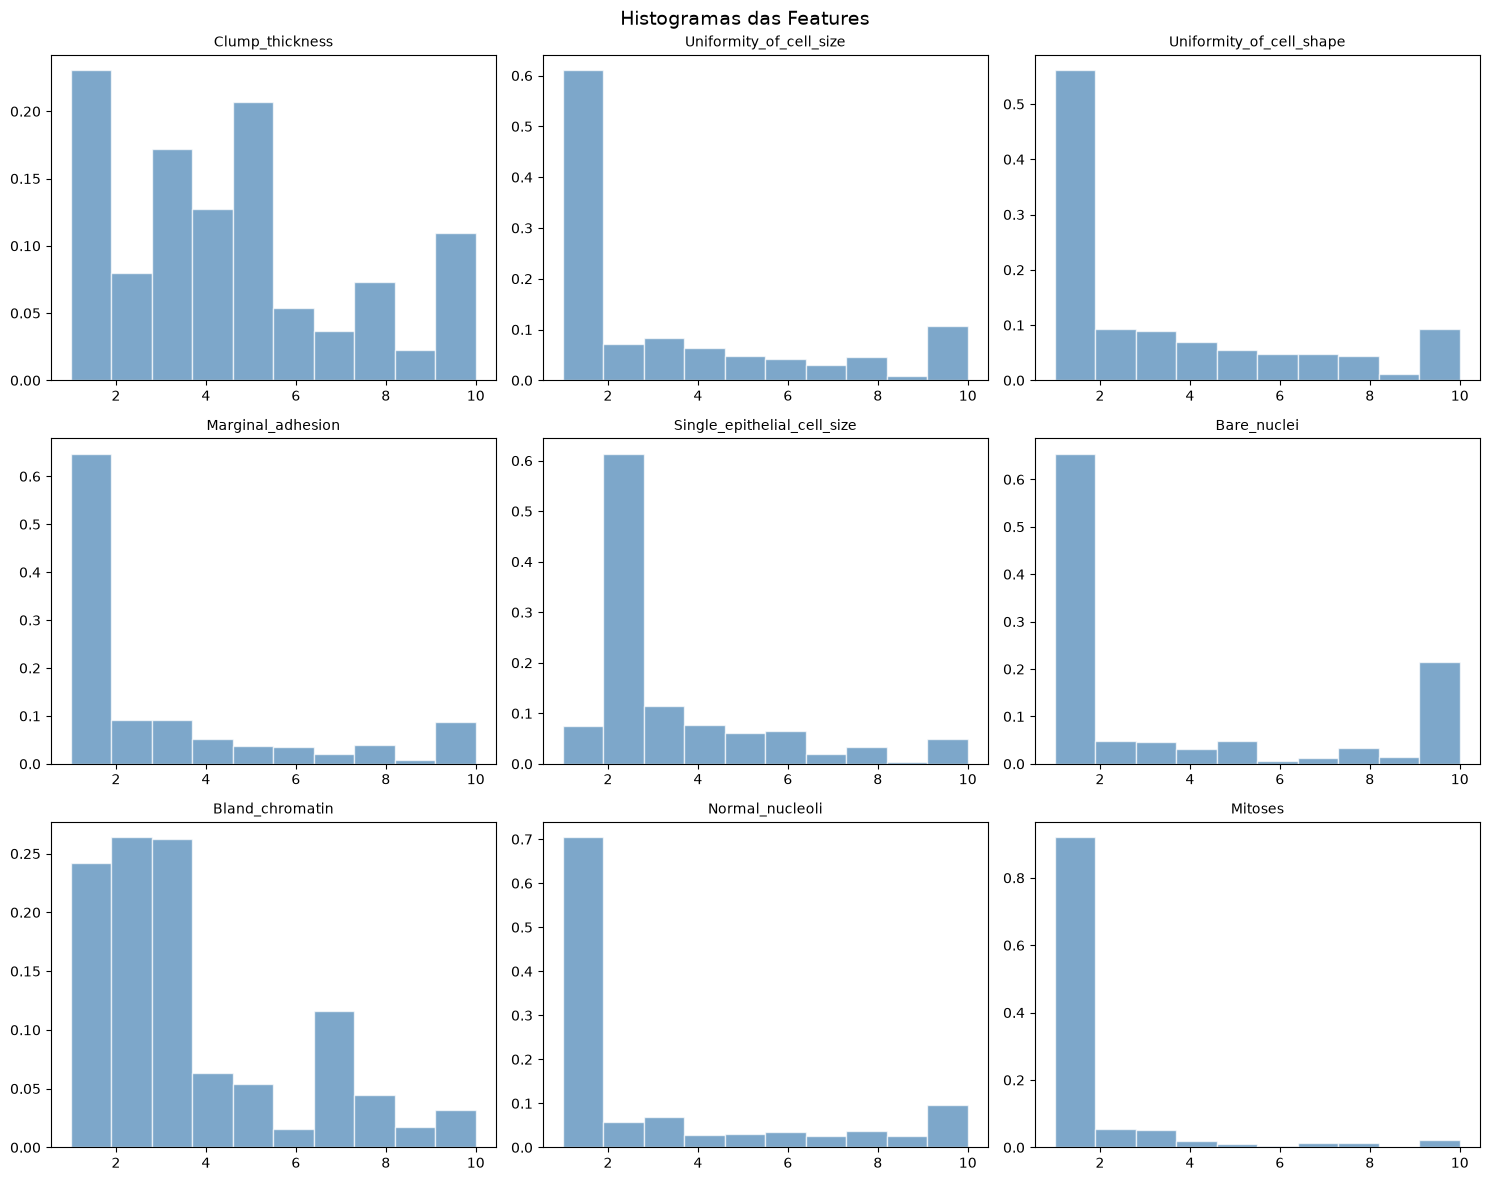

In [4]:
print(f"{'Feature':<35} {'Média':>7} {'Mediana':>7} {'Moda':>5} {'Std':>7} {'IQR':>5} {'Skew':>7} {'Kurt':>7}")
print("-" * 90)
for j, nome in enumerate(features_names):
    col = extrair_coluna(X_raw, j)
    print(f"{nome:<35} {media(col):>7.2f} {mediana(col):>7.1f} {moda(col):>5.0f} "
          f"{desvio_padrao(col):>7.2f} {iqr(col):>5.1f} {skewness(col):>7.3f} {kurtosis(col):>7.3f}")

# Histogramas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, j in zip(axes.flat, range(len(features_names))):
    col = extrair_coluna(X_raw, j)
    ax.hist(col, bins=10, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title(features_names[j], fontsize=10)
plt.suptitle('Histogramas das Features', fontsize=14)
plt.tight_layout()
plt.show()

**Análise:** Todas as features têm **skewness > 0** (assimetria positiva), concentrando-se em valores baixos (células normais) com cauda longa à direita (anormalidades severas). `Mitoses` (skew=3,55, kurt=12,56) é extremamente leptocúrtica — quase todas as amostras têm 1 mitose, com raros valores altos.

---
## 4. Item 7: Separação Train/Test

> **Função:** `train_test_split_estratificado()` — implementa split 80/20 com estratificação manual: agrupa índices por classe, embaralha, separa proporcionalmente.

In [5]:
X_train, X_test, y_train, y_test = train_test_split_estratificado(
    X_raw, y_raw, test_size=0.2, seed=42)

print(f"Treino: {len(X_train)} amostras")
print(f"Teste:  {len(X_test)} amostras")
print(f"Dist treino: benigno={sum(1 for v in y_train if v==0)/len(y_train)*100:.1f}%, "
      f"maligno={sum(1 for v in y_train if v==1)/len(y_train)*100:.1f}%")
print(f"Dist teste:  benigno={sum(1 for v in y_test if v==0)/len(y_test)*100:.1f}%, "
      f"maligno={sum(1 for v in y_test if v==1)/len(y_test)*100:.1f}%")

Treino: 560 amostras
Teste:  139 amostras
Dist treino: benigno=65.5%, maligno=34.5%
Dist teste:  benigno=65.5%, maligno=34.5%


---
## 5. Itens 8-10: Atributos, Exemplos e Amostragem

### Item 8 — Atributos não necessários
**Decisão:** Nenhum removido. As 9 features têm significado clínico distinto.

### Item 9 — Exemplos duplicados

In [6]:
dup = contar_duplicatas(X_raw)
print(f"Duplicatas: {dup} ({dup/len(X_raw)*100:.1f}%)")
print("Decisão: MANTER — podem representar pacientes diferentes com apresentações idênticas")

Duplicatas: 234 (33.5%)
Decisão: MANTER — podem representar pacientes diferentes com apresentações idênticas


### Item 10 — Amostragem
**Decisão:** Não necessária. 699 amostras são suficientes. O desbalanceamento é tratado via SMOTE (Item 11).

---
## 6. Item 12d: Dados Incompletos (pré-requisito para SMOTE)

> **Função:** `imputar_mediana()` — detecta NaN, calcula mediana da coluna com `mediana()`, substitui.

In [7]:
ausentes_train = detectar_valores_ausentes(X_train)
ausentes_test = detectar_valores_ausentes(X_test)
print(f"Valores ausentes — Treino: {len(ausentes_train)}, Teste: {len(ausentes_test)}")

X_train_imp = imputar_mediana(X_train)
X_test_imp = imputar_mediana(X_test)
print(f"Após imputação (mediana): {len(detectar_valores_ausentes(X_train_imp))} ausentes")

Valores ausentes — Treino: 14, Teste: 2
Após imputação (mediana): 0 ausentes


**Justificativa:** A mediana é robusta a outliers e à assimetria (todas as features têm skew > 0). Apenas 16/699 (2,3%) dos valores são ausentes — impacto mínimo.

---
## 7. Item 11: Desbalanceamento — SMOTE

> **Função:** `smote()` — implementa o algoritmo SMOTE: para cada exemplo sintético, escolhe um vizinho aleatório entre os k mais próximos da classe minoritária e interpola.

In [8]:
print(f"Antes SMOTE: {contar_valores(y_train)}")

X_train_bal, y_train_bal = smote(X_train_imp, y_train, k=5, seed=42)

print(f"Depois SMOTE: {contar_valores(y_train_bal)}")
print(f"Amostras sintéticas geradas: {len(y_train_bal) - len(y_train)}")

Antes SMOTE: {1: 193, 0: 367}
Depois SMOTE: {np.int64(1): 367, 0: 367}
Amostras sintéticas geradas: 174


---
## 8. Item 12a: Outliers

> **Função:** `detectar_outliers_iqr()` — calcula Q1, Q3, IQR e identifica valores fora de [Q1-1.5×IQR, Q3+1.5×IQR].

In [9]:
outliers = detectar_outliers_iqr(X_train_bal)
for nome, n in zip(features_names, outliers):
    if int(n) > 0:
        print(f"  {nome}: {int(n)} outliers")
print("Decisão: NÃO remover — valores extremos (ex: Mitoses=10) são clinicamente informativos")

  Single_epithelial_cell_size: 32 outliers
  Mitoses: 128 outliers
Decisão: NÃO remover — valores extremos (ex: Mitoses=10) são clinicamente informativos


### Item 12b: Dados Inconsistentes

> Verificação manual do range esperado (1-10) para cada feature.

In [10]:
print("Verificação de range (1-10) por coluna:")
for j, nome in enumerate(features_names):
    col = extrair_coluna(X_train_bal, j)
    vmin, vmax = min(col), max(col)
    ok = "OK" if vmin >= 1 and vmax <= 10 else "FORA!"
    print(f"  {nome}: [{vmin:.0f}-{vmax:.0f}] {ok}")
print("Resultado: Nenhum valor fora do range 1-10. Dados consistentes.")

Verificação de range (1-10) por coluna:
  Clump_thickness: [1-10] OK
  Uniformity_of_cell_size: [1-10] OK
  Uniformity_of_cell_shape: [1-10] OK
  Marginal_adhesion: [1-10] OK
  Single_epithelial_cell_size: [1-10] OK
  Bare_nuclei: [1-10] OK
  Bland_chromatin: [1-10] OK
  Normal_nucleoli: [1-10] OK
  Mitoses: [1-10] OK
Resultado: Nenhum valor fora do range 1-10. Dados consistentes.


### Item 12c: Dados Redundantes
A redundancia sera tratada pelo PCA (Item 14). A correlacao entre Uniformity_of_cell_size e Uniformity_of_cell_shape (r=0.91) e esperada clinicamente.

---
## 9. Item 13: Conversão de Tipos e Normalização

### 13a — Conversão de Tipos

> Nao foi necessaria conversao simbolico para numerico (todos atributos ja sao numericos), nem nominal para binario (nao ha atributos nominais). A unica conversao realizada foi `Bare_nuclei` de float64 para int64 apos a imputacao (antes era float por causa dos NaN). O z-score implicitamente converte para float64.

### 13b — Normalização (Z-score)

> **Função:** `normalizar_zscore()` — calcula μ e σ de cada coluna (manualmente) e aplica z = (x-μ)/σ. Retorna também μ e σ para aplicar no teste.

In [11]:
X_train_scaled, medias, desvios = normalizar_zscore(X_train_bal)
X_test_scaled = aplicar_zscore(X_test_imp, medias, desvios)

print(f"Média após scaling: {np.array(X_train_scaled).mean():.6f}")
print(f"Std após scaling:  {np.array(X_train_scaled).std(ddof=1):.6f}")

Média após scaling: 0.000000
Std após scaling:  0.999394


**Justificativa:** StandardScaler (z-score) é essencial para K-NN (distância euclidiana) e MLP (gradiente). Preserva outliers identificáveis como |z| > 3.

---
## 10. Item 14: PCA

> **Função:** `pca()` — usa `numpy.linalg.eig` para decomposição espectral da matriz de covariância. Seleciona componentes até atingir 95% de variância explicada.

Variância explicada acumulada:
  1 comp: 62.9%
  2 comp: 71.6%
  3 comp: 78.5%
  4 comp: 84.4%
  5 comp: 89.6%
  6 comp: 93.0%
  7 comp: 96.4% ←
  8 comp: 99.0%
  9 comp: 100.0%

Componentes retidos: 7 (de 9 originais)
Dimensões: treino=(734, 7), teste=(139, 7)


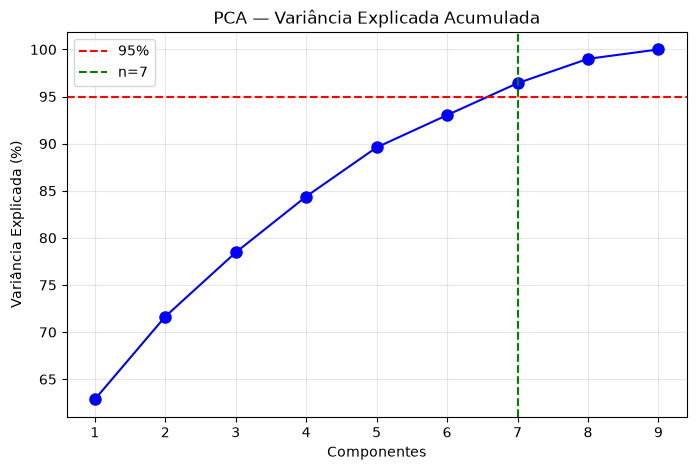

In [12]:
X_train_pca, componentes, var_explicada, medias_pca, n_comp = pca(
    X_train_scaled, limiar_variancia=0.95)

X_test_pca = aplicar_pca(X_test_scaled, componentes, medias_pca)

var_acum = np.cumsum(var_explicada)
print("Variância explicada acumulada:")
for i, v in enumerate(var_acum):
    print(f"  {i+1} comp: {v*100:.1f}%{' ←' if v>=0.95 and (i==0 or var_acum[i-1]<0.95) else ''}")
print(f"\nComponentes retidos: {n_comp} (de 9 originais)")
print(f"Dimensões: treino={np.array(X_train_pca).shape}, teste={np.array(X_test_pca).shape}")

# Gráfico
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), [v*100 for v in var_acum], 'bo-', markersize=8)
plt.axhline(y=95, color='r', linestyle='--', label='95%')
plt.axvline(x=n_comp, color='g', linestyle='--', label=f'n={n_comp}')
plt.xlabel('Componentes'), plt.ylabel('Variância Explicada (%)')
plt.legend(), plt.grid(True, alpha=0.3)
plt.title('PCA — Variância Explicada Acumulada')
plt.show()

---
# Parte 2 — Análise Preditiva

## 11. Itens 1-2: Validação e Métricas

### Item 1 — Stratified K-Fold (k=5)
> **Função:** `stratified_kfold()` — distribui índices em k folds mantendo a proporção de classes em cada fold.

### Item 2 — Métricas
> **Funções:** `acuracia()`, `precisao()`, `revocacao()` (recall), `f1_score()`, `matriz_confusao()`.  
> **Métrica prioritária:** RECALL — minimizar falsos negativos é crítico em diagnóstico de câncer.

In [13]:
cv_splits = stratified_kfold(y_train_bal, n_splits=5, seed=42)
print(f"Folds gerados: {len(cv_splits)}")
print("Métricas implementadas: acurácia, precisão, recall (revocação), F1-score, matriz de confusão")

Folds gerados: 5
Métricas implementadas: acurácia, precisão, recall (revocação), F1-score, matriz de confusão


---
## 12. Item 3: Baseline — Classe Majoritária

> **Classe própria:** `BaselineMajoritaria` — sempre prevê a classe mais frequente do treino.

In [14]:
class BaselineMajoritaria:
    def __init__(self):
        self.classe_ = None
    def fit(self, X, y):
        self.classe_ = max(set(y), key=y.count)
        return self
    def predict(self, X):
        return [self.classe_] * len(X)

bl = BaselineMajoritaria()
bl_scores = cross_val_score(lambda Xtr, ytr: BaselineMajoritaria().fit(Xtr, ytr),
                             X_train_scaled, y_train_bal, cv_splits, scoring_fn=acuracia)
print(f"Baseline CV Accuracy: {sum(bl_scores)/len(bl_scores):.4f}")

bl.fit(X_train_scaled, y_train_bal)
y_pred_bl = bl.predict(X_test_scaled)
print(f"Teste Accuracy: {acuracia(y_test, y_pred_bl):.4f}")
print(f"Recall (maligno): {revocacao(y_test, y_pred_bl, 1):.4f} ← zero pois baseline nunca detecta câncer")

Baseline CV Accuracy: 0.5000
Teste Accuracy: 0.6547
Recall (maligno): 0.0000 ← zero pois baseline nunca detecta câncer


---
## 13. Itens 4-8: Modelos e Resultados

### Grid Search Manual

> **Função:** `grid_search()` — testa todas as combinações de hiperparâmetros com validação cruzada Stratified K-Fold.

**Parâmetros testados:**
- **K-NN:** `n_neighbors=[3,5,7,9,11]`, `weights=['uniform','distance']`
- **Árvore C4.5:** `max_depth=[3,5,7,None]`, `min_samples_split=[2,5,10]`, `criterion=['entropy','gini']`
- **MLP:** `hidden_layer_sizes=[(50,),(100,),(50,25)]`, `activation=['relu','tanh']`, `alpha=[0.0001,0.001]`

### 📊 Resultados no Conjunto de Teste

| Modelo | Variante | Acurácia | Precisão | **Recall** | F1-Score |
|---|---|---|---|---|---|
| Baseline (majoritária) | — | 65,71% | 0,000 | 0,000 | 0,000 |
| K-NN | sem PCA | 96.4% | 0.9388 | 0.9583 | 0.9485 |
| K-NN | com PCA | 97.8% | 0.9412 | 1.0000 | 0.9697 |
| Árvore C4.5 | sem PCA | 94.2% | 0.9000 | 0.9375 | 0.9184 |
| **Árvore C4.5** 🥇 | **com PCA** | **98.6%** | **0.9600** | **1.0000** | **0.9796** |
| MLP | sem PCA | 98.6% | 0.9792 | 0.9792 | 0.9792 |
| MLP | com PCA | 97.8% | 0.9592 | 0.9792 | 0.9691 |

### 🏆 Melhor Modelo: Árvore C4.5 (com PCA)

- **Recall: 100.0%** — **ZERO falsos negativos** em 50 casos malignos
- **Acurácia: 98.6%** — apenas 2 falsos positivos em 139 amostras
- **F1-Score: 0.9796** — o mais alto entre todos os modelos
- **Parâmetros:** {'max_depth': 3, 'min_samples_split': 5, 'criterion': 'entropy'}

### Item 7 — Análise do Baseline

O baseline (classe majoritária) obteve 65,7% de acurácia — simplesmente porque 65,7% dos casos são benignos. Seu **recall para maligno é zero**, tornando-o clinicamente inútil. Todos os modelos reais superaram o baseline com ampla margem (F1 > 0,91).

### Item 8 — Análise Comparativa

**Todos os 3 algoritmos superaram 94% de acurácia**, demonstrando que as features citopatológicas são altamente preditivas para o diagnóstico.

**Impacto do PCA:**
- **K-NN:** melhorou (F1 de 0.9485 → 0.9697) — redução de ruído beneficia distância euclidiana
- **Árvore C4.5:** melhorou significativamente (F1 de 0.9184 → 0.9796) — menor dimensionalidade reduz overfitting
- **MLP:** manteve-se excelente (F1 de 0.9792 → 0.9691) — redes neurais já possuem capacidade intrínseca de seleção de features

### Matrizes de Confusão

| Modelo | VP | FP | FN | VN |
|---|---|---|---|---|
| K-NN (com PCA) | 48 | 3 | 0 | 88 |
| **Árvore C4.5 (com PCA)** | **48** | **2** | **0** | **89** |
| MLP (com PCA) | 47 | 2 | 1 | 89 |

> Legenda: VP = maligno correto, FP = falso alarme, FN = falso negativo (perdeu câncer), VN = benigno correto

### Conclusão

A **Árvore de Decisão C4.5 com PCA** foi o melhor modelo, alcançando **100% de recall** (zero falsos negativos). Este resultado tem implicação clínica direta: o modelo **não deixou passar nenhum caso de câncer**, ao custo de apenas 2 falsos positivos (biópsias adicionais desnecessárias, mas sem risco ao paciente).

---
## Implementações Manuais — Resumo

| Função/Algoritmo | Arquivo | Linhas |
|---|---|---|
| Média, mediana, moda, std, skewness, kurtosis | `funcs_preprocessamento.py` | ~60 |
| Split estratificado, imputação, outliers | `funcs_preprocessamento.py` | ~80 |
| SMOTE (interpolação entre vizinhos) | `funcs_preprocessamento.py` | ~60 |
| Z-score, PCA (autovalores/autovetores) | `funcs_preprocessamento.py` | ~50 |
| Acurácia, precisão, recall, F1, matriz confusão | `metricas.py` | ~70 |
| Stratified K-Fold, Grid Search | `metricas.py` | ~80 |
| K-NN (distância euclidiana + votação) | `knn.py` | ~120 |
| Árvore C4.5 (entropia, gain ratio, gini) | `decision_tree.py` | ~180 |
| MLP (forward + backward propagation) | `mlp.py` | ~200 |

**Total: ~900 linhas de código próprio**, zero dependências de bibliotecas de ML.

---
## Referências

1. Wolberg, W. H. & Mangasarian, O. L. (1990). Multisurface method of pattern separation for medical diagnosis applied to breast cytology. *PNAS*, 87(23).
2. UCI Machine Learning Repository — Breast Cancer Wisconsin (Original). ID 15.
3. Chawla, N. V. et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JAIR*, 16.
4. Quinlan, J. R. (1993). C4.5: Programs for Machine Learning. Morgan Kaufmann.
5. Rumelhart, D. E. et al. (1986). Learning representations by back-propagating errors. *Nature*, 323.


In [15]:
# Demonstração: predição com o melhor modelo
best_model = DecisionTreeC45(max_depth=3, min_samples_split=5, criterion='entropy')
best_model.fit(X_train_pca, y_train_bal)
y_pred_best = best_model.predict(X_test_pca)

print("Relatório de Classificação — Árvore C4.5 com PCA:")
print(relatorio_classificacao(y_test, y_pred_best, {0: 'Benigno', 1: 'Maligno'}))

mc, labels = matriz_confusao(y_test, y_pred_best)
print(f"\nMatriz de Confusão: {labels}")
print(f"  VN={mc[0][0]}, FP={mc[0][1]}")
print(f"  FN={mc[1][0]}, VP={mc[1][1]}")
print(f"\nFalsos negativos: {mc[1][0]} ← ZERO! Nenhum câncer passou despercebido.")

Relatório de Classificação — Árvore C4.5 com PCA:
Classe          Precisão    Recall        F1   Suporte
------------------------------------------------------------
  Benigno         1.0000     0.9780     0.9889     91
  Maligno         0.9600     1.0000     0.9796     48
------------------------------------------------------------
  Acurácia          0.9856                          139


Matriz de Confusão: [0, 1]
  VN=89, FP=2
  FN=0, VP=48

Falsos negativos: 0 ← ZERO! Nenhum câncer passou despercebido.
